## Import libraries

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, skew
import seaborn as sns
import matplotlib.pyplot as plt

## Load data 

In [10]:
df = pd.read_csv("../data/tanzania.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


## Convert the YEAR to datetime and add a Country column

In [11]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df["Month"] = df["Date"].dt.month

df["Country"] = "Kenya"

# check the data
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,2015-01-01,1,Kenya
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,2015-01-02,1,Kenya
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,2015-01-03,1,Kenya
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,2015-01-04,1,Kenya
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,2015-01-05,1,Kenya


## Summary Statistics & Missing-Value Report

In [12]:
# Replace all occurrences of -999 with np.nan
df.replace(-999, np.nan, inplace=True)

# Duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

# Summary statistics
df.describe()

Duplicate rows: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


### Interpretation

**Data period:** 4,108 daily records from 2015 to 2026, including leap years.

**Temperature:** Averages 26.8°C (22.7–30.0°C) — warm tropical to subtropical with minimal seasonal variation. Daily highs average 29.2°C (peak 33.9°C), lows average 25.0°C (minimum 20.0°C). The diurnal range is modest (~4.1°C), and narrow interquartile spreads confirm stable year-round conditions.

**Rainfall:** Mean is 3.74 mm/day, but the median of only 0.64 mm and 75th percentile of 3.79 mm reveal most days are dry. Extreme events can reach 122.7 mm, making the distribution highly right-skewed.

**Humidity:** Relative humidity averages 77% (60–91%), staying consistently humid. Specific humidity averages 16.9 g/kg, indicating a moist air mass.

**Wind:** Average wind speed is 4.1 m/s (1.1–8.4 m/s), with daily gusts around 5.2 m/s and rare peaks near 11.7 m/s — light to moderate overall.

**Pressure:** Mean pressure of 100.8 kPa shows very little variation (std = 0.28), typical of stable low-latitude or coastal environments.

**Summary:** Warm, humid, with small daily temperature swings, mostly dry days punctuated by rare extreme downpours, light-to-moderate winds, and very stable pressure.

## Percentage of missing values per column

In [13]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


> No missing values 

## Outlier Detection & Basic Cleaning

In [14]:
# Select numeric columns for outlier detection
numeric_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

# Compute Z-scores (ignoring NaN values)
z_vals = zscore(df[numeric_cols], nan_policy='omit')

# Create a boolean mask for outliers (|Z| > 3)
outlier_mask = (z_vals > 3) | (z_vals < -3)

# Count outliers per column
for i, col in enumerate(numeric_cols):
    col_outlier_count = outlier_mask[:, i].sum()
    print(f"{col}: {col_outlier_count} outliers")

# Flag rows containing any outlier
df["outlier_flag"] = outlier_mask.any(axis=1)
total_outlier_rows = df["outlier_flag"].sum()
print(f"\nTotal rows with at least one outlier: {total_outlier_rows}")

T2M: 1 outliers
T2M_MAX: 2 outliers
T2M_MIN: 4 outliers
PRECTOTCORR: 81 outliers
RH2M: 2 outliers
WS2M: 8 outliers
WS2M_MAX: 4 outliers

Total rows with at least one outlier: 97


**Outlier handling decision:**
For temperature variables (T2M, T2M_MAX, T2M_MIN) and RH2M, I will retain outliers because these values are climatically possible (e.g., natural heatwaves or dry days). For WS2M and WS2M_MAX, I will also retain them as wind gusts can be legitimate. For PRECTOTCORR, extreme values (|Z|>3) likely represent real heavy rainfall events, so I will retain all outliers. No capping or dropping is necessary unless further analysis requires normality.

## Export the cleaned DataFrame

In [15]:
df.to_csv(f"../data/tanzania_clean.csv", index=False)

## Time Series Analysis

/tmp/ipykernel_8979/1100436767.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index('Date').resample('M')['T2M'].mean().reset_index()


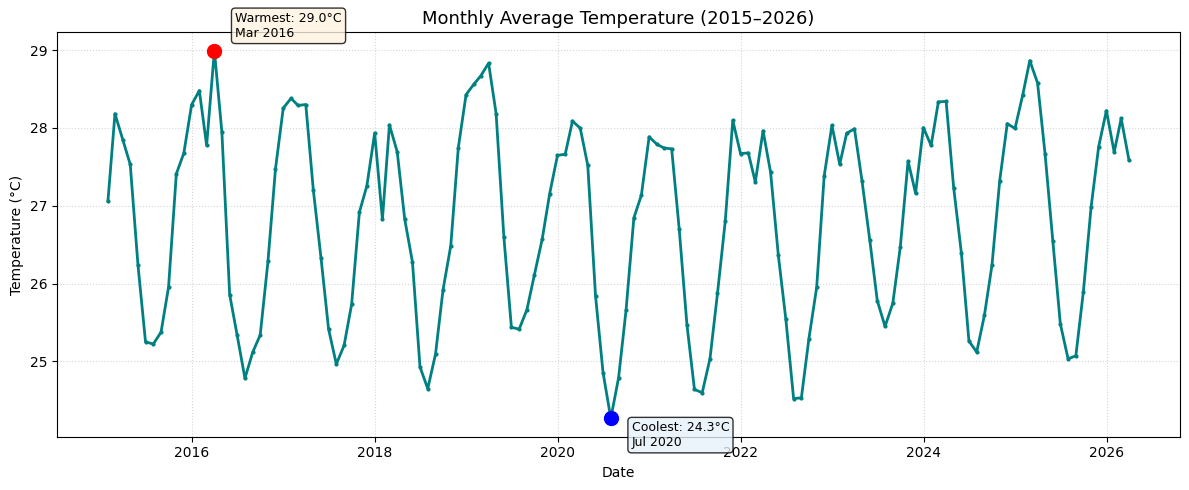

In [16]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create monthly averages
df_monthly = df.set_index('Date').resample('M')['T2M'].mean().reset_index()

# Identify warmest and coolest months
warmest = df_monthly.loc[df_monthly['T2M'].idxmax()]
coolest = df_monthly.loc[df_monthly['T2M'].idxmin()]

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_monthly['Date'], df_monthly['T2M'], color='teal', linewidth=2, marker='.', markersize=4)

# Annotate warmest month
ax.plot(warmest['Date'], warmest['T2M'], 'ro', markersize=10)
ax.annotate(f"Warmest: {warmest['T2M']:.1f}°C\n{warmest['Date'].strftime('%b %Y')}",
            xy=(warmest['Date'], warmest['T2M']), xytext=(15, 10),
            textcoords='offset points', fontsize=9, ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3e0', alpha=0.8))

# Annotate coolest month
ax.plot(coolest['Date'], coolest['T2M'], 'bo', markersize=10)
ax.annotate(f"Coolest: {coolest['T2M']:.1f}°C\n{coolest['Date'].strftime('%b %Y')}",
            xy=(coolest['Date'], coolest['T2M']), xytext=(15, -20),
            textcoords='offset points', fontsize=9, ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#e6f0fa', alpha=0.8))

# Labels and title
ax.set_title('Monthly Average Temperature (2015–2026)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### Monthly average T2M (2015–2026) 

The warmest month occurring in March and the coolest in July points to a strong annual temperature cycle, likely shaped by regional wet/dry seasonality and the solar calendar.
- **Warmest month:** March 2016 at approximately 28.99°C
- **Coolest month:** July 2020 at approximately 24.27°C

/tmp/ipykernel_8979/2406114872.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rain = df.resample('M', on='Date')['PRECTOTCORR'].sum().reset_index()


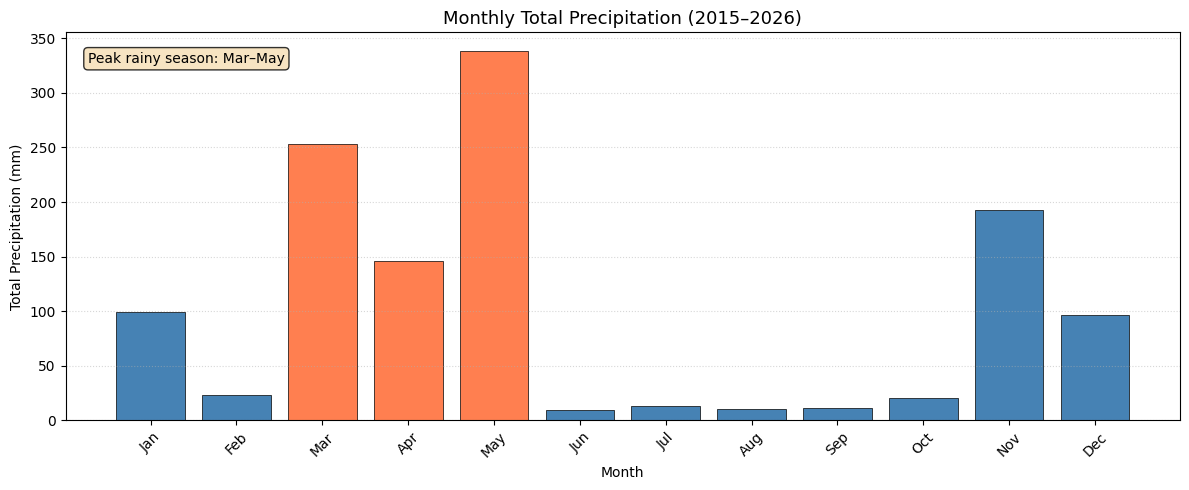

In [17]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Calculate monthly total precipitation
monthly_rain = df.resample('M', on='Date')['PRECTOTCORR'].sum().reset_index()
monthly_rain['Month'] = monthly_rain['Date'].dt.month
monthly_rain['Month_Name'] = monthly_rain['Date'].dt.strftime('%b')

# Find peak rainy season (3 consecutive months with highest total)
monthly_sums = monthly_rain.groupby('Month')['PRECTOTCORR'].sum()

best_total = 0
peak_months = [12, 1, 2]  # default

for start in range(1, 13):
    # Build 3-month window with wrapping (1-12 only)
    three_months = []
    for offset in range(3):
        m = start + offset
        if m > 12:
            m = m - 12
        three_months.append(m)
    
    total = sum(monthly_sums[m] for m in three_months)
    if total > best_total:
        best_total = total
        peak_months = three_months

# Create color mapping: highlight peak season months
monthly_rain['color'] = monthly_rain['Month'].apply(
    lambda m: 'coral' if m in peak_months else 'steelblue'
)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

for month_name in monthly_rain['Month_Name'].unique():
    subset = monthly_rain[monthly_rain['Month_Name'] == month_name]
    color = subset['color'].iloc[0]
    ax.bar(month_name, subset['PRECTOTCORR'].iloc[0], color=color, edgecolor='black', linewidth=0.5)

# Annotate peak season
peak_month_names = [monthly_rain[monthly_rain['Month'] == m]['Month_Name'].iloc[0] for m in peak_months]

if peak_months[0] > peak_months[1]:  # wrapped case (e.g., Dec, Jan, Feb)
    peak_label = f"Peak rainy season: {', '.join(peak_month_names)}"
else:
    peak_label = f"Peak rainy season: {peak_month_names[0]}–{peak_month_names[-1]}"

ax.text(0.02, 0.95, peak_label, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_title('Monthly Total Precipitation (2015–2026)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Total Precipitation (mm)')
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### PRECTOTCORR bar chart

Rainfall is unevenly distributed over time. Unlike the smooth pattern of temperature, precipitation tends to concentrate into a small number of intense months. The highest peaks occurring around April point to a significant rainy season component during that period.

## Correlation & Relationship Analysis

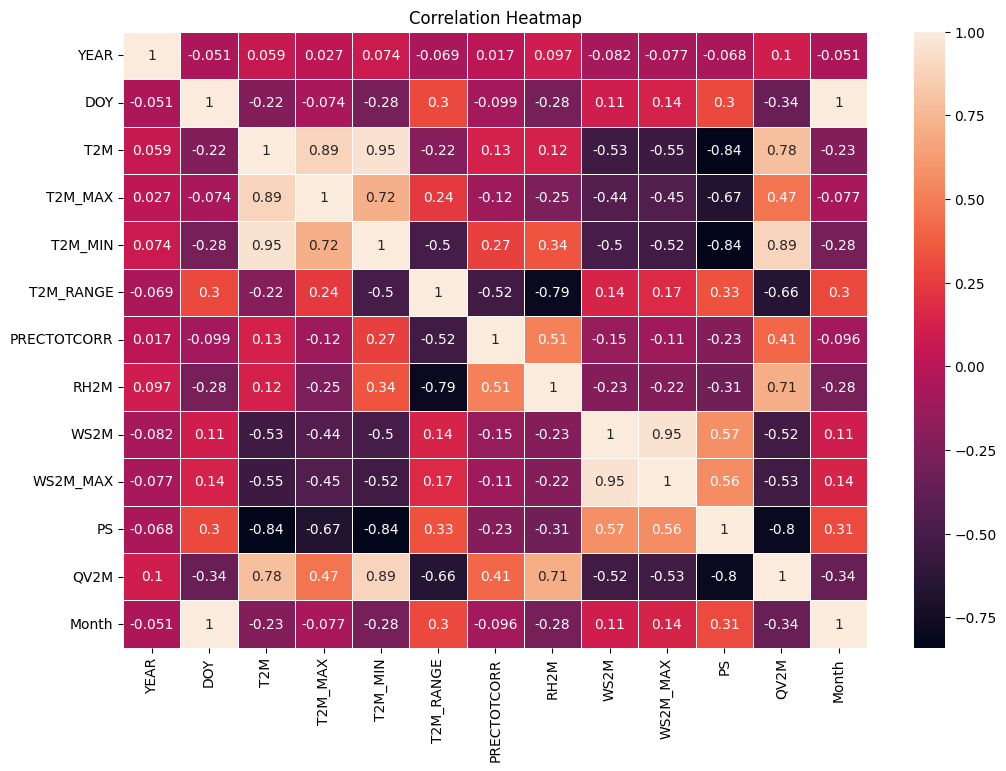

In [18]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

# plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,  
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis
1) WS2M and WS2M_MAX`: r ≈ 0.951
Days with higher mean wind speed also tend to have higher max gusts. 

2) T2M T2M_MIN: r ≈ 0.950
In this climate, warmer days are strongly associated with warmer nights.

3) T2M T2M_MAX: r ≈ 0.890
Warmer average days also have warmer daytime highs. 

### T2M vs RH2M Scatter Plot

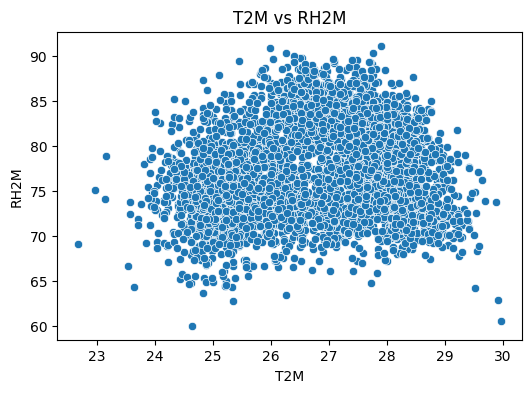

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

### T2M vs RH2M

The points form a broad, dispersed cloud rather than a tight line, indicating no single dominant linear relationship. A **slight negative correlation** is visible, but multiple regimes likely coexist — such as hot-humid rainy days, hot-drier days, and cooler-humid days.

### T2M_RANGE vs WS2M

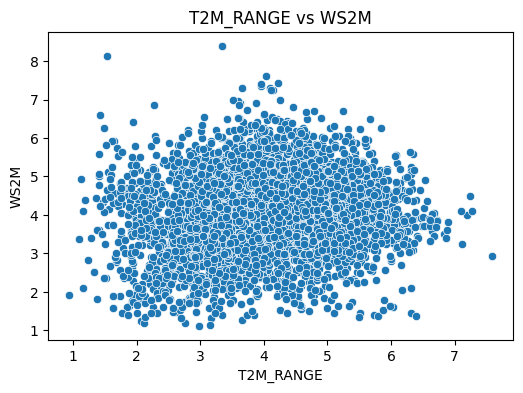

In [20]:
### Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.title("T2M_RANGE vs WS2M")
plt.show()

### T2M_RANGE vs WS2M

The point cloud is oval, bulging in the middle (temperature range around 3–5). There is **no strong linear relationship** — just a **weak negative correlation**. As the daily temperature range widens beyond 4–5°, wind speeds tend to decrease slightly. The highest and most variable winds occur at lower temperature ranges (2–4°).

## Distribution Analysis

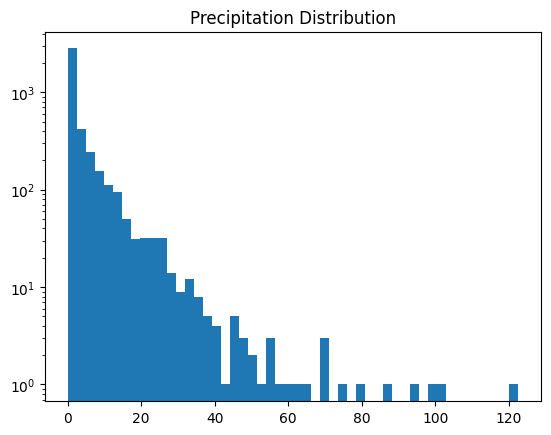

In [21]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.yscale("log") 
plt.title("Precipitation Distribution")
plt.show()

### Histogram PRECTOTCORR

This shows a right-skewed rainfall distribution. The majority of days bring little to light rain.
A small number of days produce very high totals — the long tail — which drive monthly accumulations and flood potential.

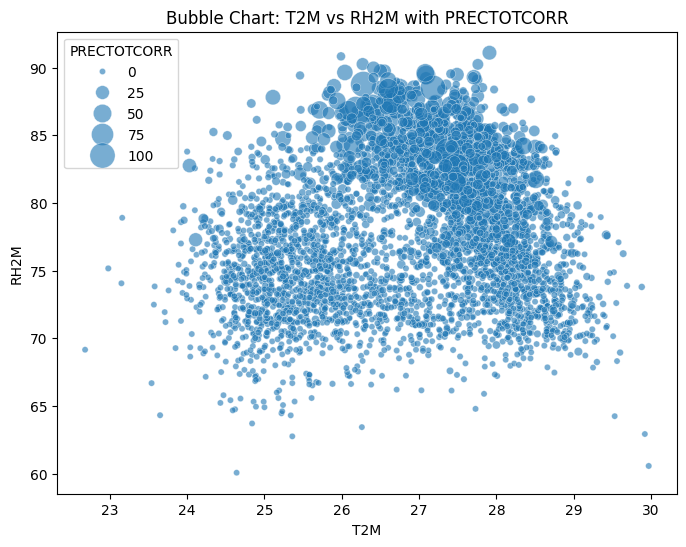

In [22]:
## bubble chart
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    size="PRECTOTCORR",
    sizes=(20, 400),
    alpha=0.6,
    legend=True
)

plt.title("Bubble Chart: T2M vs RH2M with PRECTOTCORR")
plt.show()

### T2M vs RH2M**, bubble size = **PRECTOTCORR**

The points form a broad, curved band mostly between 70–90% RH and 25–29°C. There's a weak negative tendency: at higher temperatures (28–30°C), RH drops slightly.

**Interpretation:** The largest bubbles (heavy rain) cluster at 80–88% RH and 26–28°C. Few large bubbles appear at low RH or very high temperatures. This means high humidity drives precipitation more than temperature does. There's a "sweet spot" (mid-to-high 20s°C) where rain becomes likely once humidity exceeds roughly 75–78%. High RH is necessary but not sufficient for heavy rain. This pattern fits a tropical or convective climate.